In [1]:
import random
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.nn import functional as F

from torchsummary import summary

import torchvision.transforms as T
from torchvision.datasets import MNIST

from sklearn.manifold import TSNE

import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
def make_fig(z, targets, epoch):

    model = TSNE()
    transformed = model.fit_transform(z)

    plt.scatter(transformed[:, 0], transformed[:, 1], c=targets, alpha=.4, s=3**2)

    plt.savefig(fname=f'{epoch}.png', format='png')

In [3]:
LR = 0.0001
EPOCH = 600
BATCH_SIZE = 256 + 128

LATENT_DIM = 3

In [4]:
train = MNIST('./', train=True, download=True, transform=T.ToTensor())
test = MNIST('./', train=False, download=True, transform=T.ToTensor())

train_loader = torch.utils.data.DataLoader(train, batch_size=BATCH_SIZE, num_workers=2, shuffle=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=BATCH_SIZE)

In [5]:
class Residual(nn.Module):
    def __init__(self, channel):
        super(Residual, self).__init__()

        self.conv1 = nn.Conv2d(channel, channel, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(channel, channel, kernel_size=3, stride=1, padding=1)

        self.leaky = nn.LeakyReLU(inplace=False)

    def forward(self, x):
        out = self.leaky(self.conv1(x))
        out = self.conv2(out)
        out = out + x
        return self.leaky(out)

    
class Pooling(nn.Module):
    def __init__(self, in_channel, out_channel):
        super(Pooling, self).__init__()

        self.conv1 = nn.Conv2d(in_channel, out_channel, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(out_channel, out_channel, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(out_channel, out_channel, kernel_size=3, stride=1, padding=1)

        self.leaky = nn.LeakyReLU(inplace=False)

    def forward(self, x):
        out_ = self.leaky(self.conv1(x))
        out = self.leaky(self.conv2(out_))
        out = self.conv3(out)
        out = out + out_
        return self.leaky(out)

In [6]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()

        self.block_1 = nn.Sequential(Residual(11), Pooling(11, 16))  # 14
        self.block_2 = nn.Sequential(Residual(16), Pooling(16, 32))  # 7

        self.fc_mu = nn.Linear(32*7*7, LATENT_DIM)
        self.fc_var = nn.Linear(32*7*7, LATENT_DIM)

        self.leaky = nn.LeakyReLU(inplace=False)

    def forward(self, x, y):
        ## 생성 조건 입력 방법으로 one-hot encoding 사용
        y = F.one_hot(y, num_classes=10).reshape((y.size()[0], 10, 1, 1))
        y = (torch.ones(x.size()).cuda()) * y
        
        ## 생성 조건을 channel 축으로 연결(concatenate)하는 이유는?
        x = torch.cat((x, y), dim=1)

        out = self.block_1(x)
        out = self.block_2(out)

        out = out.view(out.size(0), -1)

        mu = self.fc_mu(out)
        log_var = self.fc_var(out)

        return mu, log_var

In [7]:
class Transpose(nn.Module):
    def __init__(self, in_channel, out_channel):
        super(Transpose, self).__init__()

        self.conv_trans = nn.ConvTranspose2d(in_channels=in_channel,
                                             out_channels=out_channel,
                                             kernel_size=4, stride=2, padding=1)
        self.conv1 = nn.Conv2d(out_channel, out_channel, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(out_channel, out_channel, kernel_size=3, stride=1, padding=1)
        
        self.leaky = nn.LeakyReLU(inplace=False)

    def forward(self, x):
        out_ = self.leaky(self.conv_trans(x))
        out = self.leaky(self.conv1(out_))
        out = self.conv2(out)
        out = out + out_
        return out

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()

        self.fc = nn.Linear(LATENT_DIM + 10, 32*7*7)

        self.transpose_1 = Transpose(32, 16)
        self.transpose_2 = Transpose(16, 1)

        self.leaky = nn.LeakyReLU(inplace=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, y):
        y = F.one_hot(y, num_classes=10)
        x = torch.cat((x, y), dim=1)

        out = self.leaky(self.fc(x))
        out = out.view(out.size(0), 32, 7, 7)

        out = self.leaky(self.transpose_1(out))
        out = self.transpose_2(out)

        return self.sigmoid(out)

In [8]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x, y):
        mu, log_var = self.encoder(x, y)

        z = self.reparameterize(mu, log_var)

        recon = self.decoder(z, y)

        return recon, mu, log_var
    
    def loss_function(self, target, recon, mu, log_var):
        recon_loss = F.binary_cross_entropy(recon, target, reduction='sum')
        kld_loss = 0.5 * torch.sum(mu.pow(2) + log_var.exp() - log_var - 1)

        loss = recon_loss + kld_loss

        return loss

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu
    
    def generate(self, y):
        x = torch.rand(1, LATENT_DIM).cuda()
        return self.decoder(x, y)[0]
    
    def get_z(self, x, y):
        mu, log_var = self.encoder(x, y)

        return self.reparameterize(mu, log_var)

In [9]:
model = Model().cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 100, 200, 300, 400])

summary(model, input_size=(1, 28, 28))

Layer (type:depth-idx)                   Param #
├─Encoder: 1-1                           --
|    └─Sequential: 2-1                   --
|    |    └─Residual: 3-1                2,200
|    |    └─Pooling: 3-2                 6,240
|    └─Sequential: 2-2                   --
|    |    └─Residual: 3-3                4,640
|    |    └─Pooling: 3-4                 23,136
|    └─Linear: 2-3                       4,707
|    └─Linear: 2-4                       4,707
|    └─LeakyReLU: 2-5                    --
├─Decoder: 1-2                           --
|    └─Linear: 2-6                       21,952
|    └─Transpose: 2-7                    --
|    |    └─ConvTranspose2d: 3-5         8,208
|    |    └─Conv2d: 3-6                  2,320
|    |    └─Conv2d: 3-7                  2,320
|    |    └─LeakyReLU: 3-8               --
|    └─Transpose: 2-8                    --
|    |    └─ConvTranspose2d: 3-9         257
|    |    └─Conv2d: 3-10                 10
|    |    └─Conv2d: 3-11              

Layer (type:depth-idx)                   Param #
├─Encoder: 1-1                           --
|    └─Sequential: 2-1                   --
|    |    └─Residual: 3-1                2,200
|    |    └─Pooling: 3-2                 6,240
|    └─Sequential: 2-2                   --
|    |    └─Residual: 3-3                4,640
|    |    └─Pooling: 3-4                 23,136
|    └─Linear: 2-3                       4,707
|    └─Linear: 2-4                       4,707
|    └─LeakyReLU: 2-5                    --
├─Decoder: 1-2                           --
|    └─Linear: 2-6                       21,952
|    └─Transpose: 2-7                    --
|    |    └─ConvTranspose2d: 3-5         8,208
|    |    └─Conv2d: 3-6                  2,320
|    |    └─Conv2d: 3-7                  2,320
|    |    └─LeakyReLU: 3-8               --
|    └─Transpose: 2-8                    --
|    |    └─ConvTranspose2d: 3-9         257
|    |    └─Conv2d: 3-10                 10
|    |    └─Conv2d: 3-11              

In [10]:
for epoch in range(EPOCH):
    model.train()
    for img, target in tqdm(train_loader, leave=False, total=len(train_loader)):
        img = img.cuda()
        target = target.cuda()

        recon, mu, log_var = model(img, target)

        optimizer.zero_grad()

        loss = model.loss_function(img, recon, mu, log_var)

        loss.backward()
        optimizer.step()
        
    if not epoch % 100:
        print(loss)

tensor(42095.6367, device='cuda:0', grad_fn=<AddBackward0>)


tensor(11436.3672, device='cuda:0', grad_fn=<AddBackward0>)


tensor(11341.5371, device='cuda:0', grad_fn=<AddBackward0>)


tensor(11344.9648, device='cuda:0', grad_fn=<AddBackward0>)


tensor(11149.1963, device='cuda:0', grad_fn=<AddBackward0>)


tensor(12093.2207, device='cuda:0', grad_fn=<AddBackward0>)


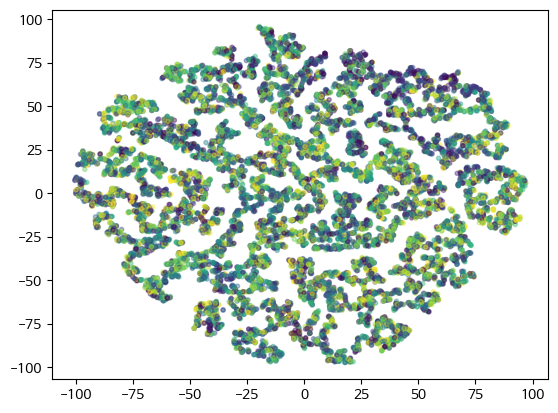

In [11]:
model.eval()
with torch.no_grad():
    features = torch.tensor([]).cuda()
    targets = torch.tensor([]).cuda()
    for (img, target) in train_loader:
        img = img.cuda()
        target = target.cuda()

        z = model.get_z(img, target)

        features = torch.cat((features, z), 0)
        targets = torch.cat((targets, target), 0)

features = features.cpu().numpy()
targets = targets.cpu().numpy()
make_fig(features[:15000], targets[:15000], 'train')

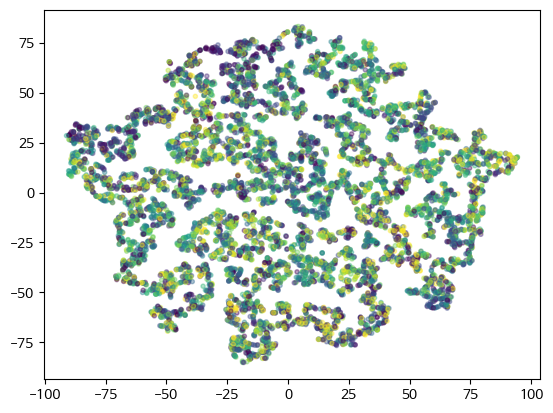

In [12]:
with torch.no_grad():
    features = torch.tensor([]).cuda()
    targets = torch.tensor([]).cuda()
    for (img, target) in test_loader:
        img = img.cuda()
        target = target.cuda()

        z = model.get_z(img, target)

        features = torch.cat((features, z), 0)
        targets = torch.cat((targets, target), 0)

features = features.cpu().numpy()
targets = targets.cpu().numpy()
make_fig(features[:], targets[:], 'test')

In [13]:
n = torch.Tensor([1])
n = n.to(torch.int64).cuda()
T.functional.to_pil_image(model.generate(n))

In [14]:
class Encoder(nn.Module):
    def __init__(self, embedding_size):
        super(Encoder, self).__init__()

        self.block_1 = nn.Sequential(Residual(1+embedding_size), Pooling(1+embedding_size, 16))  # 14
        self.block_2 = nn.Sequential(Residual(16), Pooling(16, 32))  # 7

        self.fc_mu = nn.Linear(32*7*7, LATENT_DIM)
        self.fc_var = nn.Linear(32*7*7, LATENT_DIM)

        self.leaky = nn.LeakyReLU(inplace=False)

    def forward(self, x, y):
        y = y.reshape(-1, y.size()[1], 1, 1)
        y = (torch.ones(x.size()).cuda()) * y
        x = torch.cat((x, y), dim=1)

        out = self.block_1(x)
        out = self.block_2(out)

        out = out.view(out.size(0), -1)

        mu = self.fc_mu(out)
        log_var = self.fc_var(out)

        return mu, log_var
    
    
class Decoder(nn.Module):
    def __init__(self, embedding_size):
        super(Decoder, self).__init__()

        self.fc = nn.Linear(LATENT_DIM + embedding_size, 32*7*7)

        self.transpose_1 = Transpose(32, 16)
        self.transpose_2 = Transpose(16, 1)

        self.leaky = nn.LeakyReLU(inplace=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, y):
        x = torch.cat((x, y), dim=1)

        out = self.leaky(self.fc(x))
        out = out.view(out.size(0), 32, 7, 7)

        out = self.leaky(self.transpose_1(out))
        out = self.transpose_2(out)

        return self.sigmoid(out)

In [15]:
class Model(nn.Module):
    def __init__(self, nclass=10, embedding_size=8):
        super(Model, self).__init__()

        self.encoder = Encoder(embedding_size)
        self.decoder = Decoder(embedding_size)
        
        ## 학습 가능한 embedding vector를 학습 조건으로 사용
        self.label_embedding = nn.Embedding(nclass, embedding_size)

    def forward(self, x, y):
        y = self.label_embedding(y)
        mu, log_var = self.encoder(x, y)

        z = self.reparameterize(mu, log_var)

        recon = self.decoder(z, y)

        return recon, mu, log_var
    
    def loss_function(self, target, recon, mu, log_var):
        recon_loss = F.binary_cross_entropy(recon, target, reduction='sum')
        kld_loss = 0.5 * torch.sum(mu.pow(2) + log_var.exp() - log_var - 1)

        loss = recon_loss + kld_loss

        return loss

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu
    
    def generate(self, **kwargs):
        x = torch.rand(1, LATENT_DIM).cuda()
        return self.decoder(x)[0]
    
    def get_z(self, x, y):
        y = self.label_embedding(y)
        mu, log_var = self.encoder(x, y)

        return self.reparameterize(mu, log_var)

In [16]:
model = Model().cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 100, 200, 300, 400])

summary(model, input_size=(1, 28, 28))
for epoch in range(EPOCH):
    model.train()
    for img, target in tqdm(train_loader, leave=False, total=len(train_loader)):
        img = img.cuda()
        target = target.cuda()

        recon, mu, log_var = model(img, target)

        optimizer.zero_grad()

        loss = model.loss_function(img, recon, mu, log_var)

        loss.backward()
        optimizer.step()
        
    if not epoch % 100:
        print(loss)

Layer (type:depth-idx)                   Param #
├─Encoder: 1-1                           --
|    └─Sequential: 2-1                   --
|    |    └─Residual: 3-1                1,476
|    |    └─Pooling: 3-2                 5,952
|    └─Sequential: 2-2                   --
|    |    └─Residual: 3-3                4,640
|    |    └─Pooling: 3-4                 23,136
|    └─Linear: 2-3                       4,707
|    └─Linear: 2-4                       4,707
|    └─LeakyReLU: 2-5                    --
├─Decoder: 1-2                           --
|    └─Linear: 2-6                       18,816
|    └─Transpose: 2-7                    --
|    |    └─ConvTranspose2d: 3-5         8,208
|    |    └─Conv2d: 3-6                  2,320
|    |    └─Conv2d: 3-7                  2,320
|    |    └─LeakyReLU: 3-8               --
|    └─Transpose: 2-8                    --
|    |    └─ConvTranspose2d: 3-9         257
|    |    └─Conv2d: 3-10                 10
|    |    └─Conv2d: 3-11              

tensor(55649.3516, device='cuda:0', grad_fn=<AddBackward0>)


tensor(12153.6172, device='cuda:0', grad_fn=<AddBackward0>)


tensor(11681.5449, device='cuda:0', grad_fn=<AddBackward0>)


tensor(11639.4512, device='cuda:0', grad_fn=<AddBackward0>)


tensor(12053.9521, device='cuda:0', grad_fn=<AddBackward0>)


tensor(11363.2998, device='cuda:0', grad_fn=<AddBackward0>)


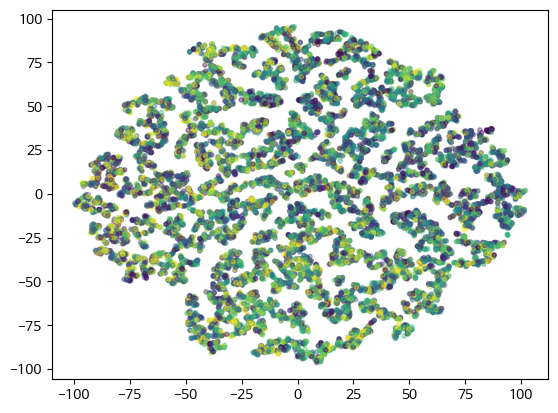

In [17]:
model.eval()
with torch.no_grad():
    features = torch.tensor([]).cuda()
    targets = torch.tensor([]).cuda()
    for (img, target) in train_loader:
        img = img.cuda()
        target = target.cuda()

        z = model.get_z(img, target)

        features = torch.cat((features, z), 0)
        targets = torch.cat((targets, target), 0)

features = features.cpu().numpy()
targets = targets.cpu().numpy()
make_fig(features[:15000], targets[:15000], 'train')

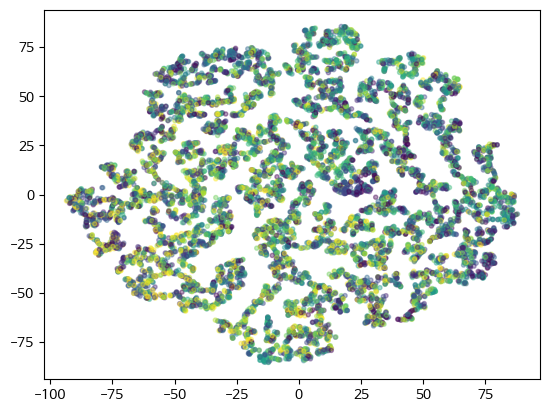

In [18]:
with torch.no_grad():
    features = torch.tensor([]).cuda()
    targets = torch.tensor([]).cuda()
    for (img, target) in test_loader:
        img = img.cuda()
        target = target.cuda()

        z = model.get_z(img, target)

        features = torch.cat((features, z), 0)
        targets = torch.cat((targets, target), 0)

features = features.cpu().numpy()
targets = targets.cpu().numpy()
make_fig(features[:], targets[:], 'test')